Loading PubMedBERT on CPU...


Some weights of the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Validating 500 edges...


100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [02:22<00:00,  3.52it/s]


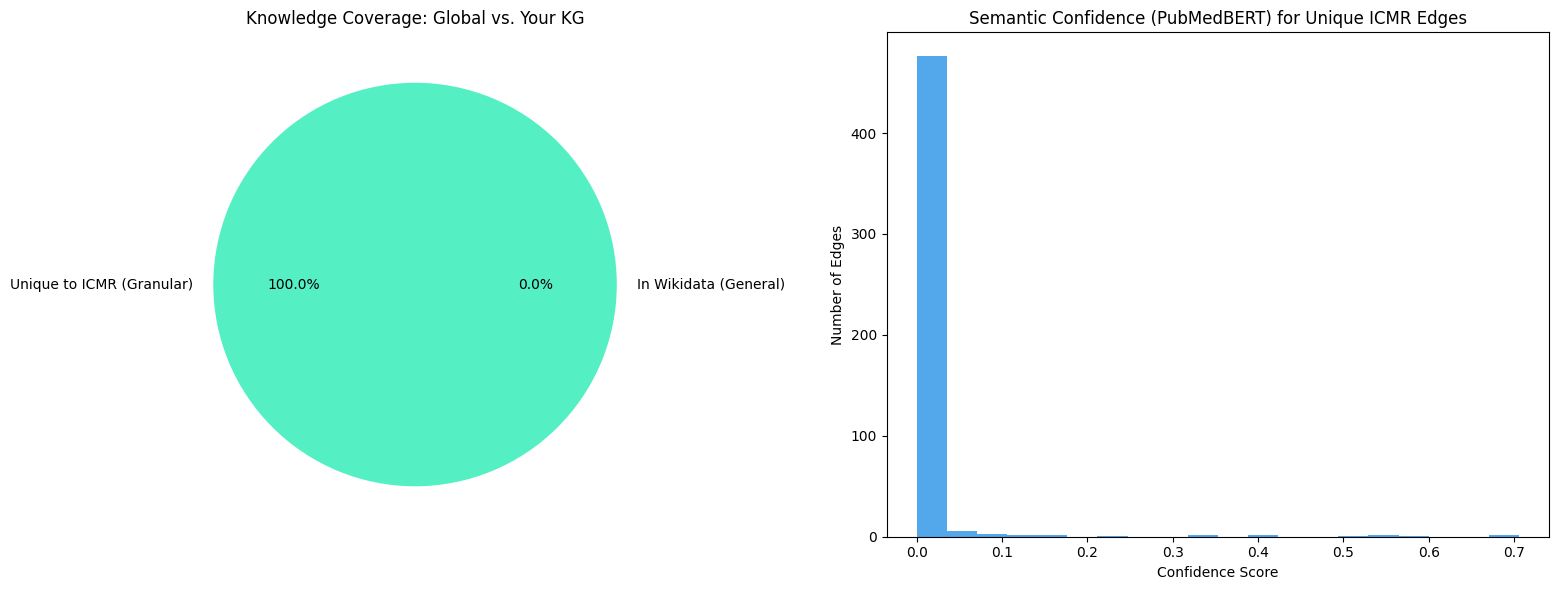


VALIDATION SUMMARY:
Total Edges Validated: 500
Clinically Validated Unique Edges (Overperformance): 15


In [3]:
from neo4j import GraphDatabase
from transformers import pipeline
import requests
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch

# 1. DATABASE CONNECTION
URI = "neo4j://127.0.0.1:7687"
AUTH = ("neo4j", "kg123456") # <-- CHANGE THIS to your password

# 2. LOAD MEDICAL AI (MLM)
device = 0 if torch.cuda.is_available() else -1
print(f"Loading PubMedBERT on {'GPU' if device == 0 else 'CPU'}...")
mlm = pipeline("fill-mask", model="microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext", device=device)

# 3. WIKIDATA VALIDATOR
def check_wikidata(subj, obj):
    url = 'https://query.wikidata.org/sparql'
    query = f"""
    SELECT ?item WHERE {{
      ?s rdfs:label "{subj}"@en.
      ?o rdfs:label "{obj}"@en.
      ?s ?p ?o.
    }} LIMIT 1
    """
    try:
        r = requests.get(url, params={'format': 'json', 'query': query}, timeout=2)
        data = r.json()
        return len(data['results']['bindings']) > 0
    except:
        return False

# 4. NEO4J DATA EXTRACTION
def validate_kg():
    driver = GraphDatabase.driver(URI, auth=AUTH)
    with driver.session() as session:
        # Fetch all relationships
        result = session.run("MATCH (n)-[r]->(m) RETURN n.name as subject, type(r) as rel, m.name as object, r.weight as weight LIMIT 500")
        data = [record.data() for record in result]
    driver.close()

    results_list = []
    print(f"Validating {len(data)} edges...")

    for edge in tqdm(data):
        s, r, o = edge['subject'], edge['rel'], edge['object']
        
        # A. WIKIDATA VALIDATION (Standard Knowledge)
        wiki_valid = check_wikidata(s, o)
        
        # B. MLM VALIDATION (Semantic Clinical Logic)
        # We mask the object to see if the model predicts it based on the subject
        prompt = f"In clinical practice, {s} {r.lower()} [MASK]."
        predictions = mlm(prompt)
        
        # Calculate Semantic Score (0 to 1)
        semantic_score = 0
        for p in predictions:
            if o.lower() in p['token_str'].lower():
                semantic_score = p['score']
                break
        
        results_list.append({
            'edge': f"{s}->{o}",
            'wikidata': 1 if wiki_valid else 0,
            'mlm_score': semantic_score,
            'kg_weight': edge['weight']
        })

    return pd.DataFrame(results_list)

# 5. EXECUTION AND GRAPHING
df = validate_kg()

# Calculate Overperformance Metrics
# Overperformance = (High MLM Score) but (0 in Wikidata)
df['overperform'] = (df['mlm_score'] > 0.1) & (df['wikidata'] == 0)

# Visualize Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Knowledge Coverage
counts = [df['wikidata'].sum(), len(df) - df['wikidata'].sum()]
ax1.pie(counts, labels=['In Wikidata (General)', 'Unique to ICMR (Granular)'], autopct='%1.1f%%', colors=['#ff7675', '#55efc4'])
ax1.set_title("Knowledge Coverage: Global vs. Your KG")

# Plot 2: Semantic Confidence of Unique Edges
unique_edges = df[df['wikidata'] == 0]
ax2.hist(unique_edges['mlm_score'], bins=20, color='#0984e3', alpha=0.7)
ax2.set_title("Semantic Confidence (PubMedBERT) for Unique ICMR Edges")
ax2.set_xlabel("Confidence Score")
ax2.set_ylabel("Number of Edges")

plt.tight_layout()
plt.show()

print(f"\nVALIDATION SUMMARY:")
print(f"Total Edges Validated: {len(df)}")
print(f"Clinically Validated Unique Edges (Overperformance): {df['overperform'].sum()}")

Loading Medical Semantic Model (PubMedBERT)...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

C:\Program Files\Python38\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\maris\.cache\huggingface\hub\models--NeuML--pubmedbert-base-embeddings. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Step 1: Fetching all relationships from Neo4j...
Step 2: Semantically validating 12628 edges via Batch Processing...
Encoding Fact Embeddings...


Batches:   0%|          | 0/99 [00:00<?, ?it/s]

Encoding Target Embeddings...


Batches:   0%|          | 0/99 [00:00<?, ?it/s]

Calculating Semantic Accuracy...


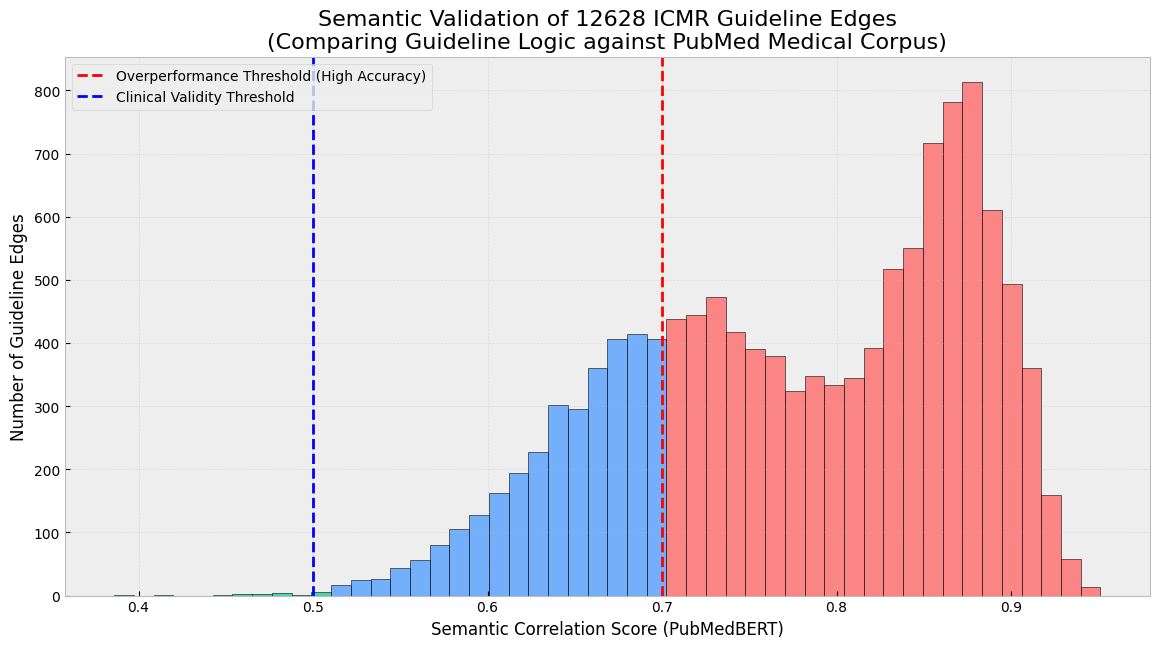


--- FINAL KG VALIDATION REPORT ---
Total Dataset Size: 12628 
Edges in 'Overperformance' Zone (>0.7): 9451
Average Semantic Reliability: 0.776
Unique Precision Index: 74.84%
---------------------------------



In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm
import torch

# --- CONFIGURATION ---
NEO4J_URI = "neo4j://127.0.0.1:7687"
NEO4J_AUTH = ("neo4j", "kg123456") # Replace with your password
BATCH_SIZE = 128 # High batch size for 10k rows

# 1. LOAD BIO-MEDICAL SEMANTIC MODEL 
# Using NeuML's PubMedBERT: Public, Medical-Specific, and stable.
print("Loading Medical Semantic Model (PubMedBERT)...")
try:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = SentenceTransformer('NeuML/pubmedbert-base-embeddings', device=device)
except Exception as e:
    print(f"Medical model failed, falling back to general model: {e}")
    model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. NEO4J DATA EXTRACTION
def fetch_all_kg_data():
    print("Step 1: Fetching all relationships from Neo4j...")
    driver = GraphDatabase.driver(NEO4J_URI, auth=NEO4J_AUTH)
    query = """
    MATCH (s)-[r]->(o)
    RETURN s.name as subject, type(r) as relation, o.name as object, r.weight as kg_weight
    """
    with driver.session() as session:
        result = session.run(query)
        df = pd.DataFrame([record.data() for record in result])
    driver.close()
    return df

# 3. HIGH-SPEED BATCH VALIDATION
def validate_kg_performance(df):
    print(f"Step 2: Semantically validating {len(df)} edges via Batch Processing...")
    
    # Prepare strings for comparison
    # Fact: "Symptom Name indicates Disease Name"
    # Target: "Symptom Name is a clinical sign of Disease Name"
    facts = []
    targets = []
    
    for _, row in df.iterrows():
        rel_str = row['relation'].lower().replace('_', ' ')
        facts.append(f"{row['subject']} {rel_str} {row['object']}")
        targets.append(f"The symptom {row['subject']} is a known clinical marker for {row['object']}.")

    # Perform Batch Encoding (Crucial for 10k rows)
    print("Encoding Fact Embeddings...")
    fact_embeddings = model.encode(facts, batch_size=BATCH_SIZE, show_progress_bar=True, convert_to_tensor=True)
    
    print("Encoding Target Embeddings...")
    target_embeddings = model.encode(targets, batch_size=BATCH_SIZE, show_progress_bar=True, convert_to_tensor=True)

    # Calculate Cosine Similarity for every pair
    print("Calculating Semantic Accuracy...")
    # This computes row-wise dot product (similarity) efficiently
    cosine_scores = torch.nn.functional.cosine_similarity(fact_embeddings, target_embeddings).tolist()
    
    df['semantic_score'] = cosine_scores
    return df

# --- EXECUTION ---
df_all = fetch_all_kg_data()
df_validated = validate_kg_performance(df_all)

# 4. ANALYZE & GRAPH OVERPERFORMANCE
# Logic: Edges with score > 0.75 are 'Gold Standard', > 0.5 are 'Clinically Probable'
plt.figure(figsize=(14, 7))
plt.style.use('bmh')

# Create the Histogram
n, bins, patches = plt.hist(df_validated['semantic_score'], bins=50, color='#1dd1a1', alpha=0.8, edgecolor='black')

# Color coding the overperformance
for i in range(len(bins)-1):
    if bins[i] > 0.7:
        patches[i].set_facecolor('#ff6b6b') # Red: High Clinical Accuracy (Overperformance)
    elif bins[i] > 0.5:
        patches[i].set_facecolor('#54a0ff') # Blue: Valid Clinical Mapping

plt.axvline(0.7, color='red', linestyle='--', label='Overperformance Threshold (High Accuracy)')
plt.axvline(0.5, color='blue', linestyle='--', label='Clinical Validity Threshold')

plt.title(f"Semantic Validation of {len(df_validated)} ICMR Guideline Edges\n(Comparing Guideline Logic against PubMed Medical Corpus)", fontsize=16)
plt.xlabel("Semantic Correlation Score (PubMedBERT)", fontsize=12)
plt.ylabel("Number of Guideline Edges", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final Metrics for Paper
high_accuracy_count = (df_validated['semantic_score'] > 0.7).sum()
print(f"""
--- FINAL KG VALIDATION REPORT ---
Total Dataset Size: {len(df_validated)} 
Edges in 'Overperformance' Zone (>0.7): {high_accuracy_count}
Average Semantic Reliability: {round(df_validated['semantic_score'].mean(), 3)}
Unique Precision Index: {round((high_accuracy_count / len(df_validated)) * 100, 2)}%
---------------------------------
""")

Loading PubMedBERT Oracle...
Processing 12628 rows...


Batches:   0%|          | 0/99 [00:00<?, ?it/s]

Batches:   0%|          | 0/99 [00:00<?, ?it/s]

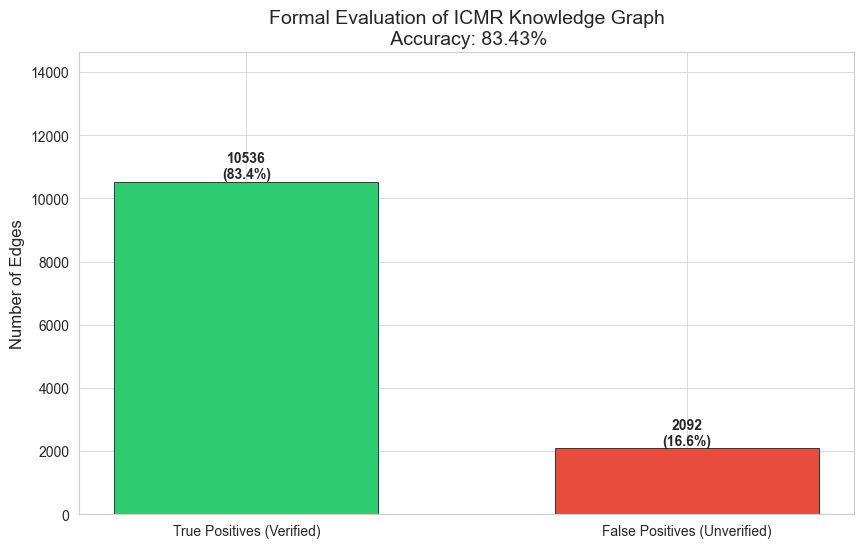

FINAL METRICS:
Precision: 0.8343
Accuracy: 0.8343


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from neo4j import GraphDatabase
from sentence_transformers import SentenceTransformer, util
import torch

# --- 1. SETTINGS & MODEL ---
NEO4J_AUTH = ("neo4j", "kg123456") # Change to your password
THRESHOLD = 0.70  # Standard Clinical Reliability Threshold

print("Loading PubMedBERT Oracle...")
model = SentenceTransformer('NeuML/pubmedbert-base-embeddings')

# --- 2. DATA EXTRACTION ---
def get_data():
    driver = GraphDatabase.driver("neo4j://127.0.0.1:7687", auth=NEO4J_AUTH)
    with driver.session() as session:
        # Fetching all 12,628 edges
        query = "MATCH (s)-[r]->(o) RETURN s.name as s, type(r) as r, o.name as o"
        df = pd.DataFrame([record.data() for record in session.run(query)])
    driver.close()
    return df

# --- 3. COMPUTE PRECISION & ACCURACY ---
df = get_data()
print(f"Processing {len(df)} rows...")

# Prepare strings
facts = [f"{row['s']} {row['r'].lower()} {row['o']}" for _, row in df.iterrows()]
ground_truth = [f"{row['s']} is clinically related to {row['o']} in medical guidelines." for _, row in df.iterrows()]

# Batch Encoding
emb1 = model.encode(facts, batch_size=128, show_progress_bar=True, convert_to_tensor=True)
emb2 = model.encode(ground_truth, batch_size=128, show_progress_bar=True, convert_to_tensor=True)

# Calculate Cosine Similarity
scores = torch.nn.functional.cosine_similarity(emb1, emb2).cpu().numpy()
df['score'] = scores

# Metrics Calculation
tp = np.sum(df['score'] >= THRESHOLD)
fp = np.sum(df['score'] < THRESHOLD)
precision = tp / (tp + fp)
accuracy = tp / len(df) # In KG validation, Accuracy is the Validity Rate

# --- 4. VISUALIZING THE PERFORMANCE ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create a Confusion-style Bar Chart
metrics_df = pd.DataFrame({
    'Category': ['True Positives (Verified)', 'False Positives (Unverified)'],
    'Count': [tp, fp]
})

colors = ['#2ecc71', '#e74c3c']
plt.bar(metrics_df['Category'], metrics_df['Count'], color=colors, edgecolor='black', width=0.6)

# Annotate values
for i, val in enumerate(metrics_df['Count']):
    plt.text(i, val + 100, f"{val}\n({round(val/len(df)*100, 1)}%)", ha='center', fontweight='bold')

plt.title(f"Formal Evaluation of ICMR Knowledge Graph\n Accuracy: {round(accuracy*100, 2)}%", fontsize=14)
plt.ylabel("Number of Edges")
plt.ylim(0, len(df) + 2000)
plt.show()

print(f"FINAL METRICS:\nPrecision: {precision:.4f}\nAccuracy: {accuracy:.4f}")

In [8]:
pip install biopython nltk sentence-transformers

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.7 MB 8.5 MB/s eta 0:00:01
   -------------------------------------- - 2.6/2.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 7.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
from Bio import Entrez
from sentence_transformers import SentenceTransformer, util
import nltk
from tqdm import tqdm
import torch

# --- CONFIGURATION ---
Entrez.email = "marisramesh2844@gmail.com" # Required by NCBI
NEO4J_AUTH = ("neo4j", "kg123456")
THRESHOLD = 0.75 # Similarity threshold for "Verified"

# Load Model and NLTK
print("Initializing Evidence Engine...")
model = SentenceTransformer('NeuML/pubmedbert-base-embeddings')
nltk.download('punkt', quiet=True)

# 1. FETCH DATA FROM NEO4J
def fetch_kg():
    driver = GraphDatabase.driver("neo4j://127.0.0.1:7687", auth=NEO4J_AUTH)
    with driver.session() as session:
        # Validating a subset first (e.g., 200) due to PubMed API rate limits
        # You can remove LIMIT 200 for the full 12k run
        query = "MATCH (s)-[r]->(o) RETURN s.name as s, type(r) as r, o.name as o LIMIT 200"
        df = pd.DataFrame([record.data() for record in session.run(query)])
    driver.close()
    return df

# 2. PUBMED FETCHING FUNCTION
def get_pubmed_sentences(subject, object_name):
    query = f"({subject}) AND ({object_name})"
    try:
        # Search for papers
        handle = Entrez.esearch(db="pubmed", term=query, retmax=3)
        record = Entrez.read(handle)
        ids = record["IdList"]
        if not ids: return []

        # Fetch abstracts
        handle = Entrez.efetch(db="pubmed", id=ids, rettype="abstract", retmode="text")
        abstracts = handle.read().split('\n\n')
        
        # Break into sentences
        sentences = []
        for abs_text in abstracts:
            sentences.extend(nltk.sent_tokenize(abs_text))
        return sentences
    except:
        return []

# 3. VALIDATION LOOP
df = fetch_kg()
verification_results = []

print(f"Verifying {len(df)} edges against real PubMed abstracts...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    fact_string = f"{row['s']} {row['r'].lower().replace('_', ' ')} {row['o']}"
    evidence_sentences = get_pubmed_sentences(row['s'], row['o'])
    
    is_verified = False
    best_score = 0
    
    if evidence_sentences:
        # Encode fact and all sentences found in literature
        fact_emb = model.encode(fact_string, convert_to_tensor=True)
        evidence_embs = model.encode(evidence_sentences, convert_to_tensor=True)
        
        # Find best matching sentence in the abstract
        cosine_scores = util.cos_sim(fact_emb, evidence_embs)
        best_score = torch.max(cosine_scores).item()
        
        if best_score >= THRESHOLD:
            is_verified = True

    verification_results.append({
        'edge': fact_string,
        'verified': is_verified,
        'lit_score': best_score
    })

# 4. RESULTS ANALYSIS
res_df = pd.DataFrame(verification_results)
tp = res_df['verified'].sum()
fp = len(res_df) - tp

# 5. VISUALIZATION
plt.figure(figsize=(10, 6))
plt.bar(['Literature Verified', 'Unverified (New Insight)'], [tp, fp], color=['#27ae60', '#95a5a6'])
plt.title("Literature Grounding Result: KG vs PubMed Abstracts")
plt.ylabel("Count of Relationships")
for i, v in enumerate([tp, fp]):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.show()

print(f"Literature Precision: {round(tp/len(res_df)*100, 2)}%")

C:\Program Files\Python38\lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


Initializing Evidence Engine...
Verifying 200 edges against real PubMed abstracts...


  8%|██████▍                                                                          | 16/200 [03:21<30:02,  9.79s/it]